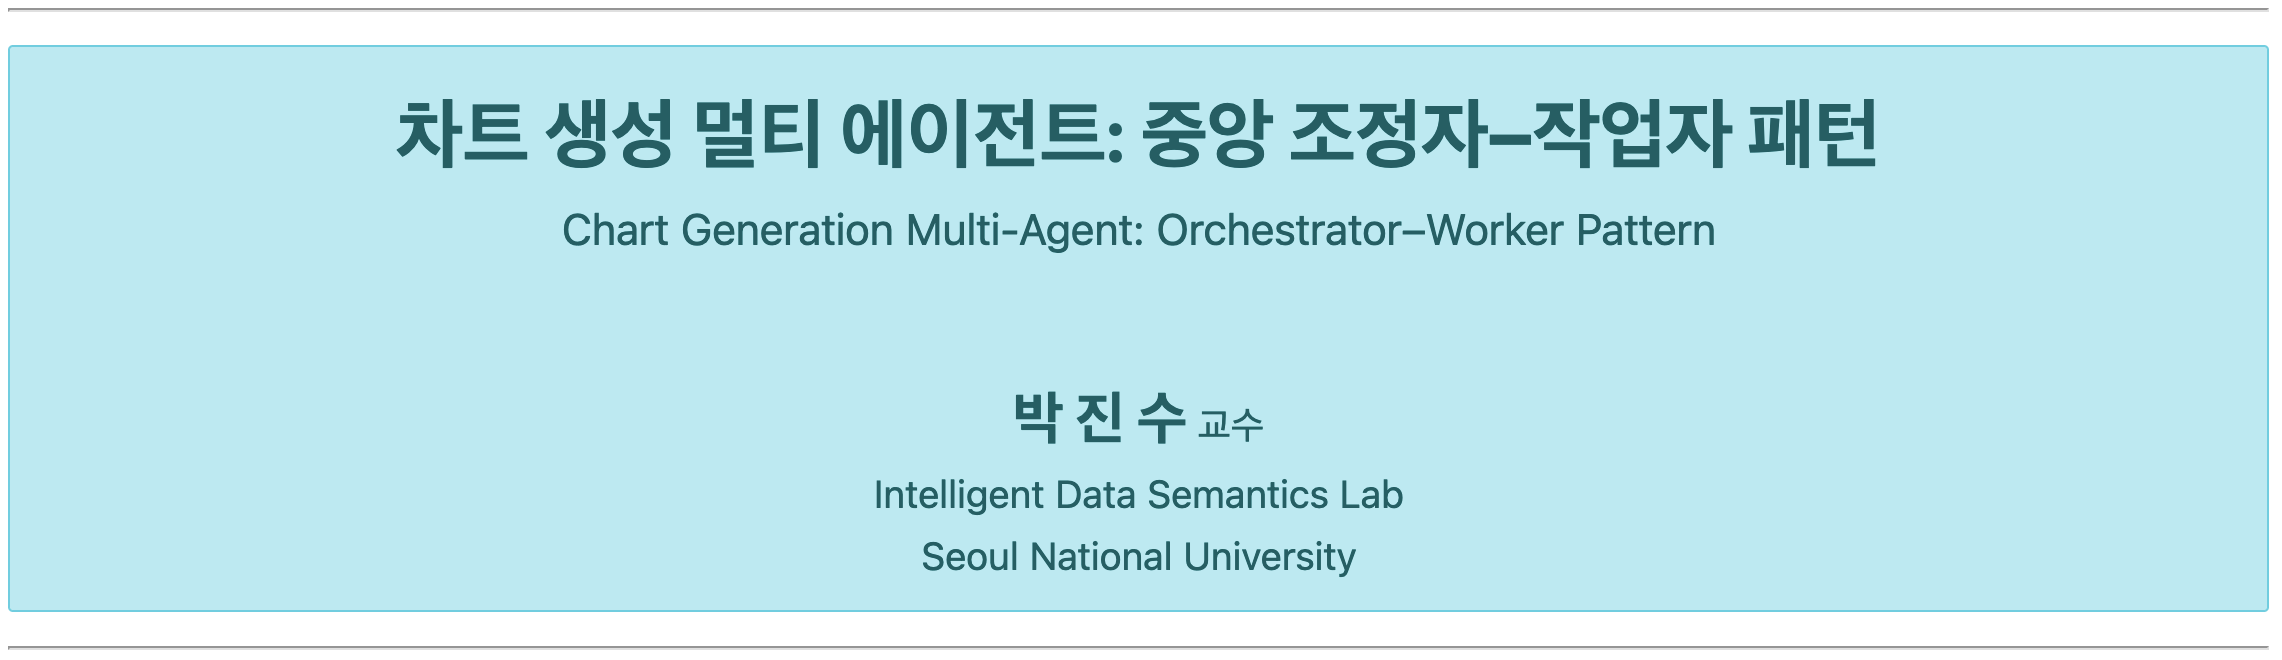

- - -    

- 본 자료는 강의를 위한 목적으로 LangChain이 제공하는 자료에 기반하여 제작했습니다.
- 본 자료에 대한 사전 허가를 받지 않는 배포를 금지합니다.
- 본 자료를 강의나 다른 목적으로 활용하고자 하시는 경우 꼭 아래 이메일 주소로 연락주세요.
- 연락처: [jinsoo@snu.ac.kr](jinsoo@snu.ac.kr)

> 파이썬 입문자라면, <http://youtube.com/@myontology>의 **[[학습 프로그램]](https://www.youtube.com/@myontology/courses)** 탭을 활용해 보세요. 기초부터 차근차근 배울 수 있는 파이썬 강의 영상이 준비되어 있어 필요한 내용을 쉽고 빠르게 학습할 수 있습니다.

- - -

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#패키지-설치-및-API-설정" data-toc-modified-id="패키지-설치-및-API-설정-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>패키지 설치 및 API 설정</a></span><ul class="toc-item"><li><span><a href="#Setting-up-Tools-API" data-toc-modified-id="Setting-up-Tools-API-1.1"><span class="toc-item-num">1.1&nbsp;&nbsp;</span>Setting up Tools API</a></span><ul class="toc-item"><li><span><a href="#Tavily" data-toc-modified-id="Tavily-1.1.1"><span class="toc-item-num">1.1.1&nbsp;&nbsp;</span>Tavily</a></span></li><li><span><a href="#Python-REPL-Tool" data-toc-modified-id="Python-REPL-Tool-1.1.2"><span class="toc-item-num">1.1.2&nbsp;&nbsp;</span>Python REPL Tool</a></span></li></ul></li><li><span><a href="#Setting-Up-LLM-API" data-toc-modified-id="Setting-Up-LLM-API-1.2"><span class="toc-item-num">1.2&nbsp;&nbsp;</span>Setting Up LLM API</a></span></li></ul></li><li><span><a href="#도우미-함수-가져오기" data-toc-modified-id="도우미-함수-가져오기-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>도우미 함수 가져오기</a></span></li><li><span><a href="#도구-정의" data-toc-modified-id="도구-정의-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>도구 정의</a></span><ul class="toc-item"><li><span><a href="#Tavily-Search-Tool" data-toc-modified-id="Tavily-Search-Tool-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Tavily Search Tool</a></span></li><li><span><a href="#Python-REPL-Tool" data-toc-modified-id="Python-REPL-Tool-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Python REPL Tool</a></span></li></ul></li><li><span><a href="#전문-작업-에이전트-구성" data-toc-modified-id="전문-작업-에이전트-구성-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>전문 작업 에이전트 구성</a></span><ul class="toc-item"><li><span><a href="#조사-에이전트" data-toc-modified-id="조사-에이전트-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>조사 에이전트</a></span></li><li><span><a href="#차트-생성-에이전트" data-toc-modified-id="차트-생성-에이전트-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>차트 생성 에이전트</a></span></li></ul></li><li><span><a href="#전문-작업-에이전트를-도구로-감싸기" data-toc-modified-id="전문-작업-에이전트를-도구로-감싸기-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>전문 작업 에이전트를 도구로 감싸기</a></span><ul class="toc-item"><li><span><a href="#조사-도구" data-toc-modified-id="조사-도구-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>조사 도구</a></span></li><li><span><a href="#차트-생성-도구" data-toc-modified-id="차트-생성-도구-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>차트 생성 도구</a></span></li></ul></li><li><span><a href="#오케스트레이터(중앙-조정)-에이전트-구성" data-toc-modified-id="오케스트레이터(중앙-조정)-에이전트-구성-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>오케스트레이터(중앙 조정) 에이전트 구성</a></span></li><li><span><a href="#실행" data-toc-modified-id="실행-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>실행</a></span></li><li><span><a href="#Lab:-멀티턴-메모리-추가하기" data-toc-modified-id="Lab:-멀티턴-메모리-추가하기-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Lab: 멀티턴 메모리 추가하기</a></span></li></ul></div>

- - -
**중앙 조정자–작업자 패턴(Orchestrator–Worker Pattern)**

핵심 개념
> 중앙 에이전트(감독 에이전트)가 작업을 분해하고,   
> 전문 에이전트(작업자/서브 에이전트)에게 위임한 뒤,  
> 결과를 통합하는 계층형 구조

구성 요소
- 중앙 조정자 (Orchestrator)
    + 요청 분석
    + 작업 분해
    + 작업자 선택
    + 결과 통합
- 작업자 (Worker)
    + 특정 도메인 전담
    + 도구 실행
    + 결과 반환

언제 사용하는가?
- 여러 서로 다른 인지 도메인(예: 수학 풀이, 코드 생성, 검색, 데이터 분석)을 동시에 다뤄야 할 때
- 하나의 에이전트가 서로 다른 추론 방식과 출력 형식을 모두 처리해야 할 때
- 계산 중심 문제와 개념 이해 및 설명 문제가 함께 포함된 과제를 다룰 때
- 특정 영역만 성능이 저하되어 도메인별로 분리 개선이 필요할 때
- 복합 학습 과제를 단계별 작업 단위로 분해해야 할 때

장점
- 도메인별 전문화 (도구를 도메인별로 분리해 복잡도를 낮춤)
- 확장 용이
- 유지보수 용이 (각 작업자를 독립적으로 개선 가능)
- 복잡도 감소
- 중앙에서 흐름을 통제하여 일관성 유지
- - -

**생성한 차트 예시**

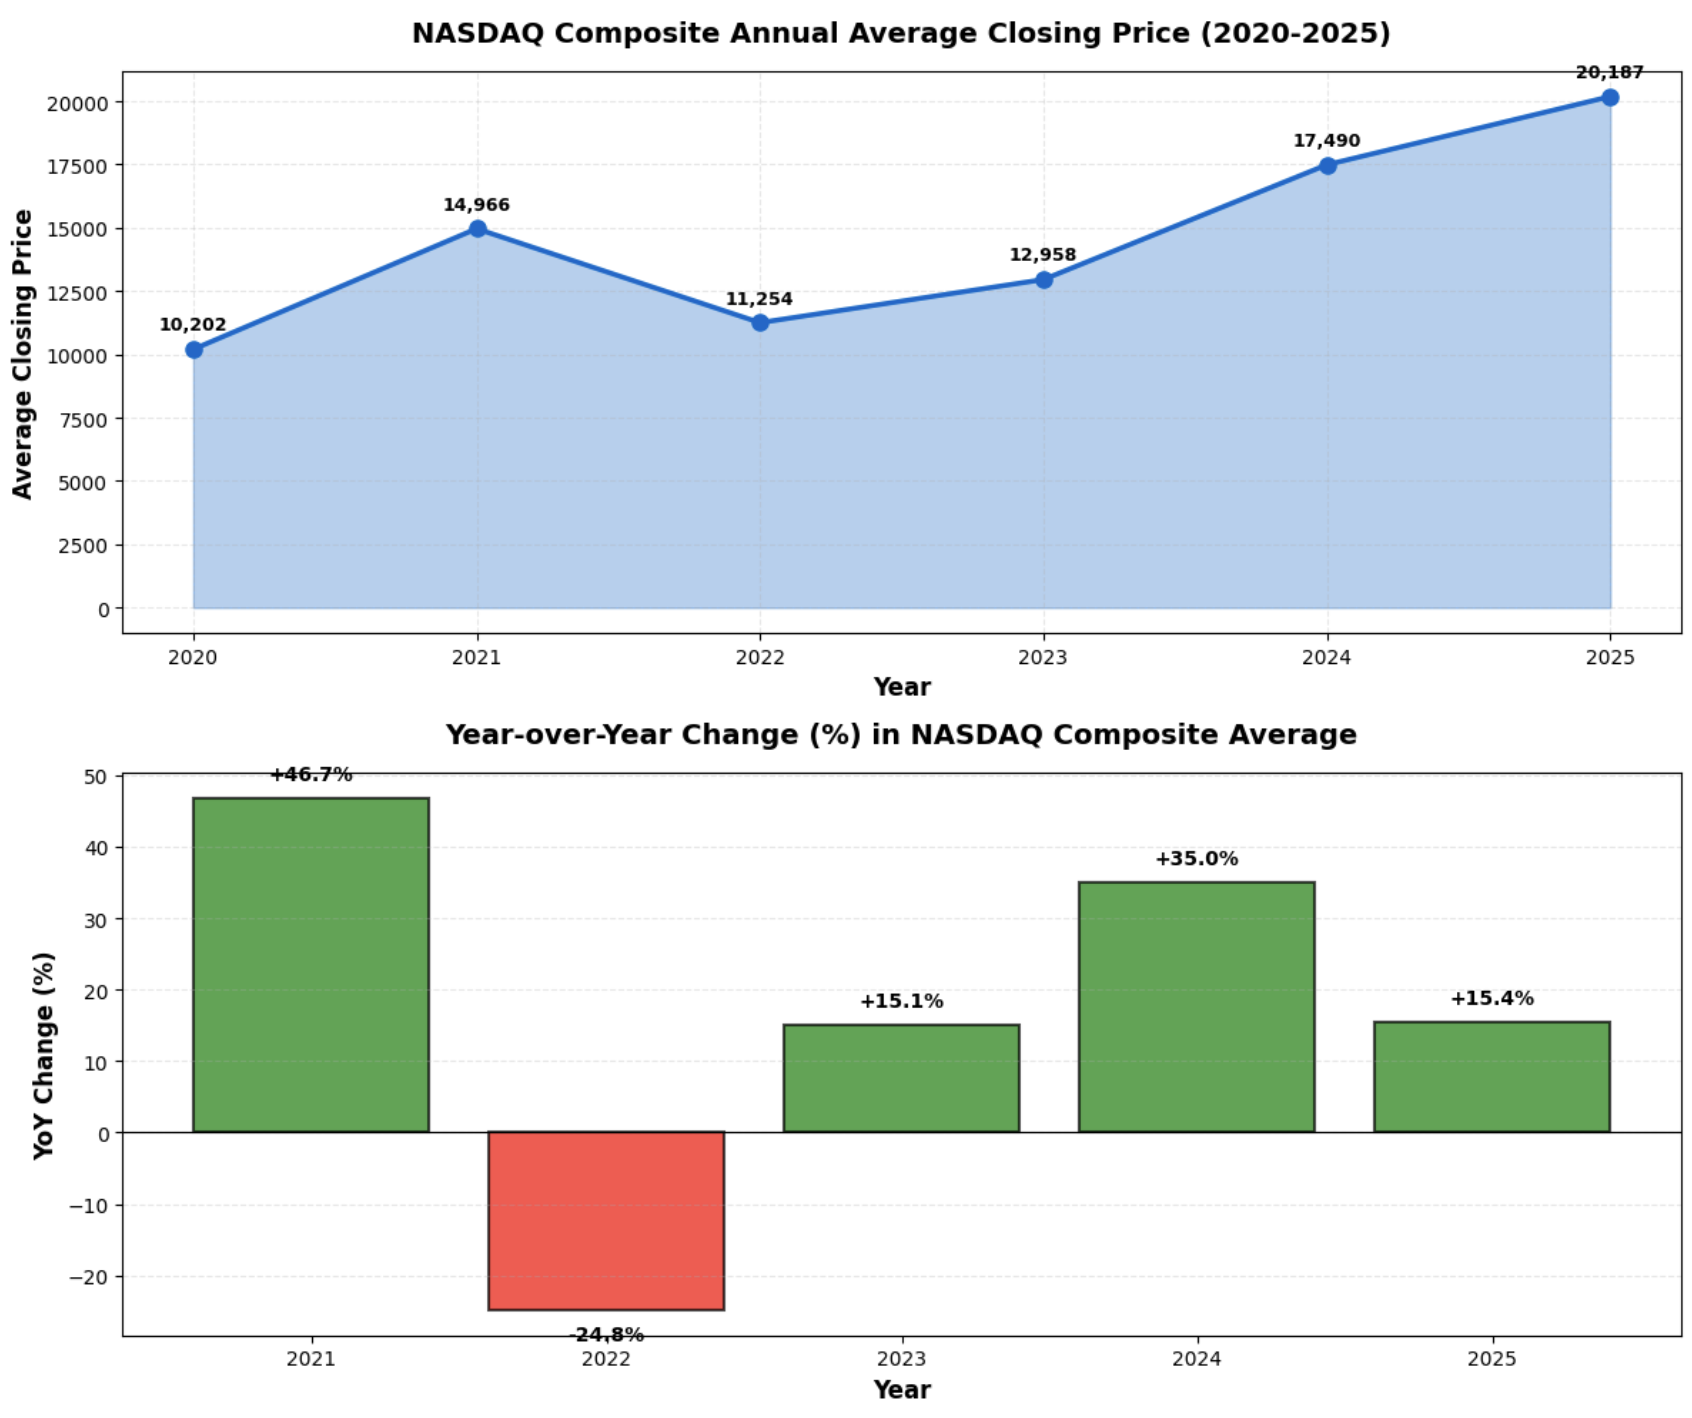

**생성한 차트 예시**

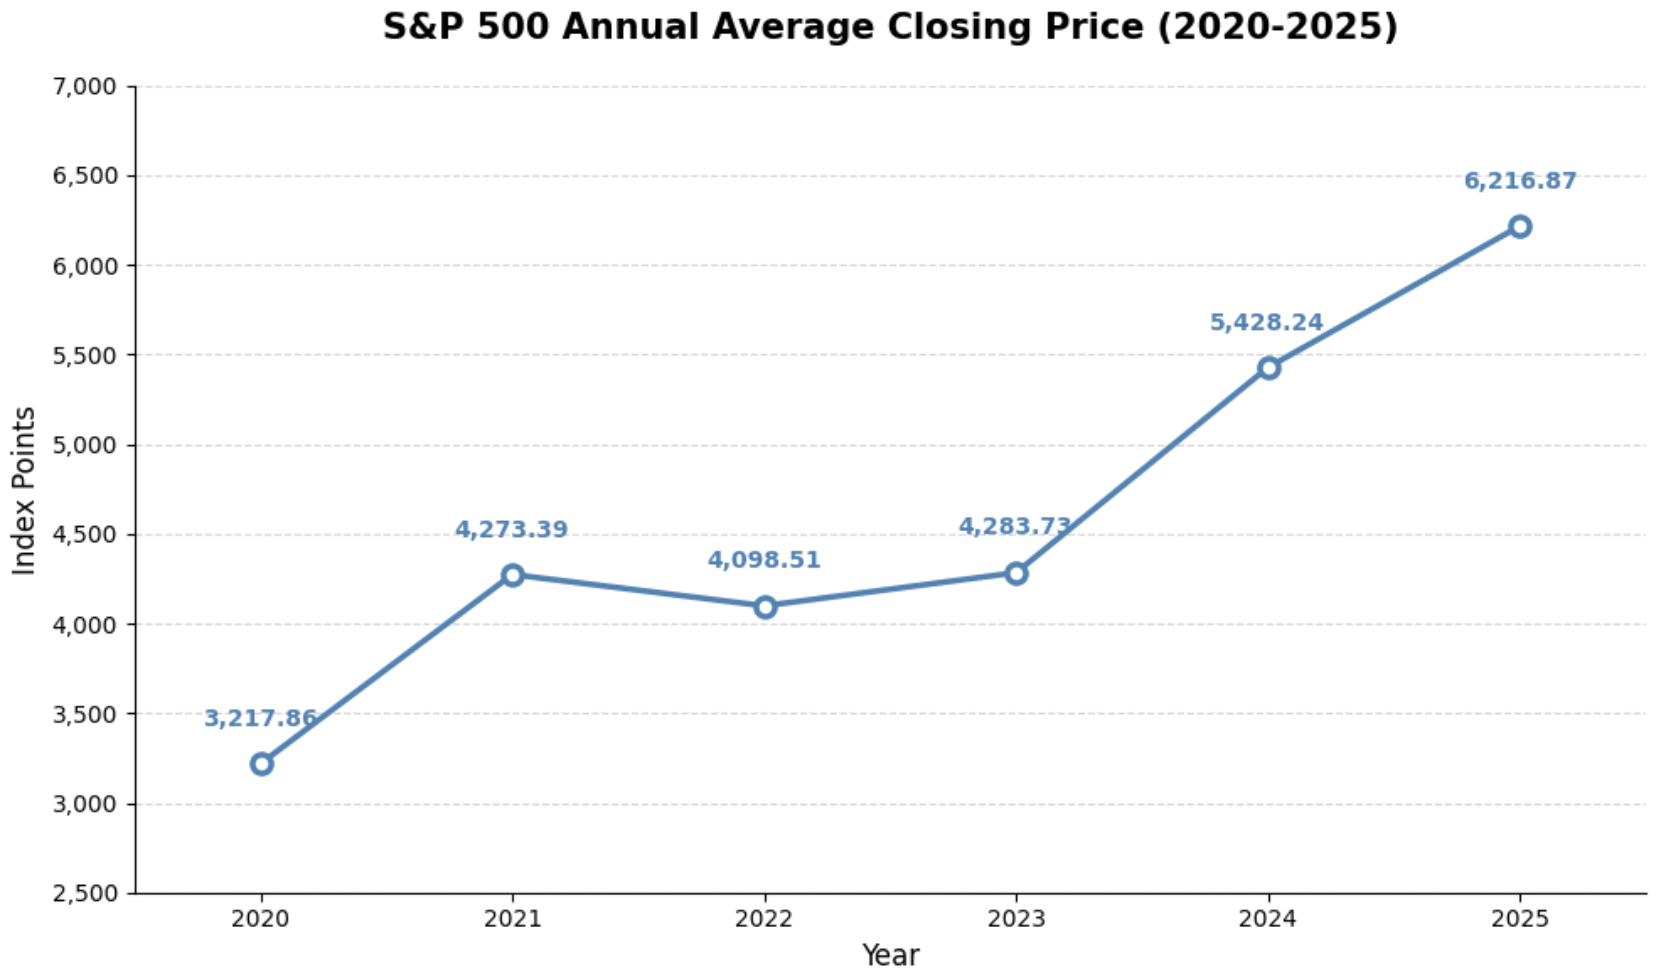

**생성한 차트 예시**

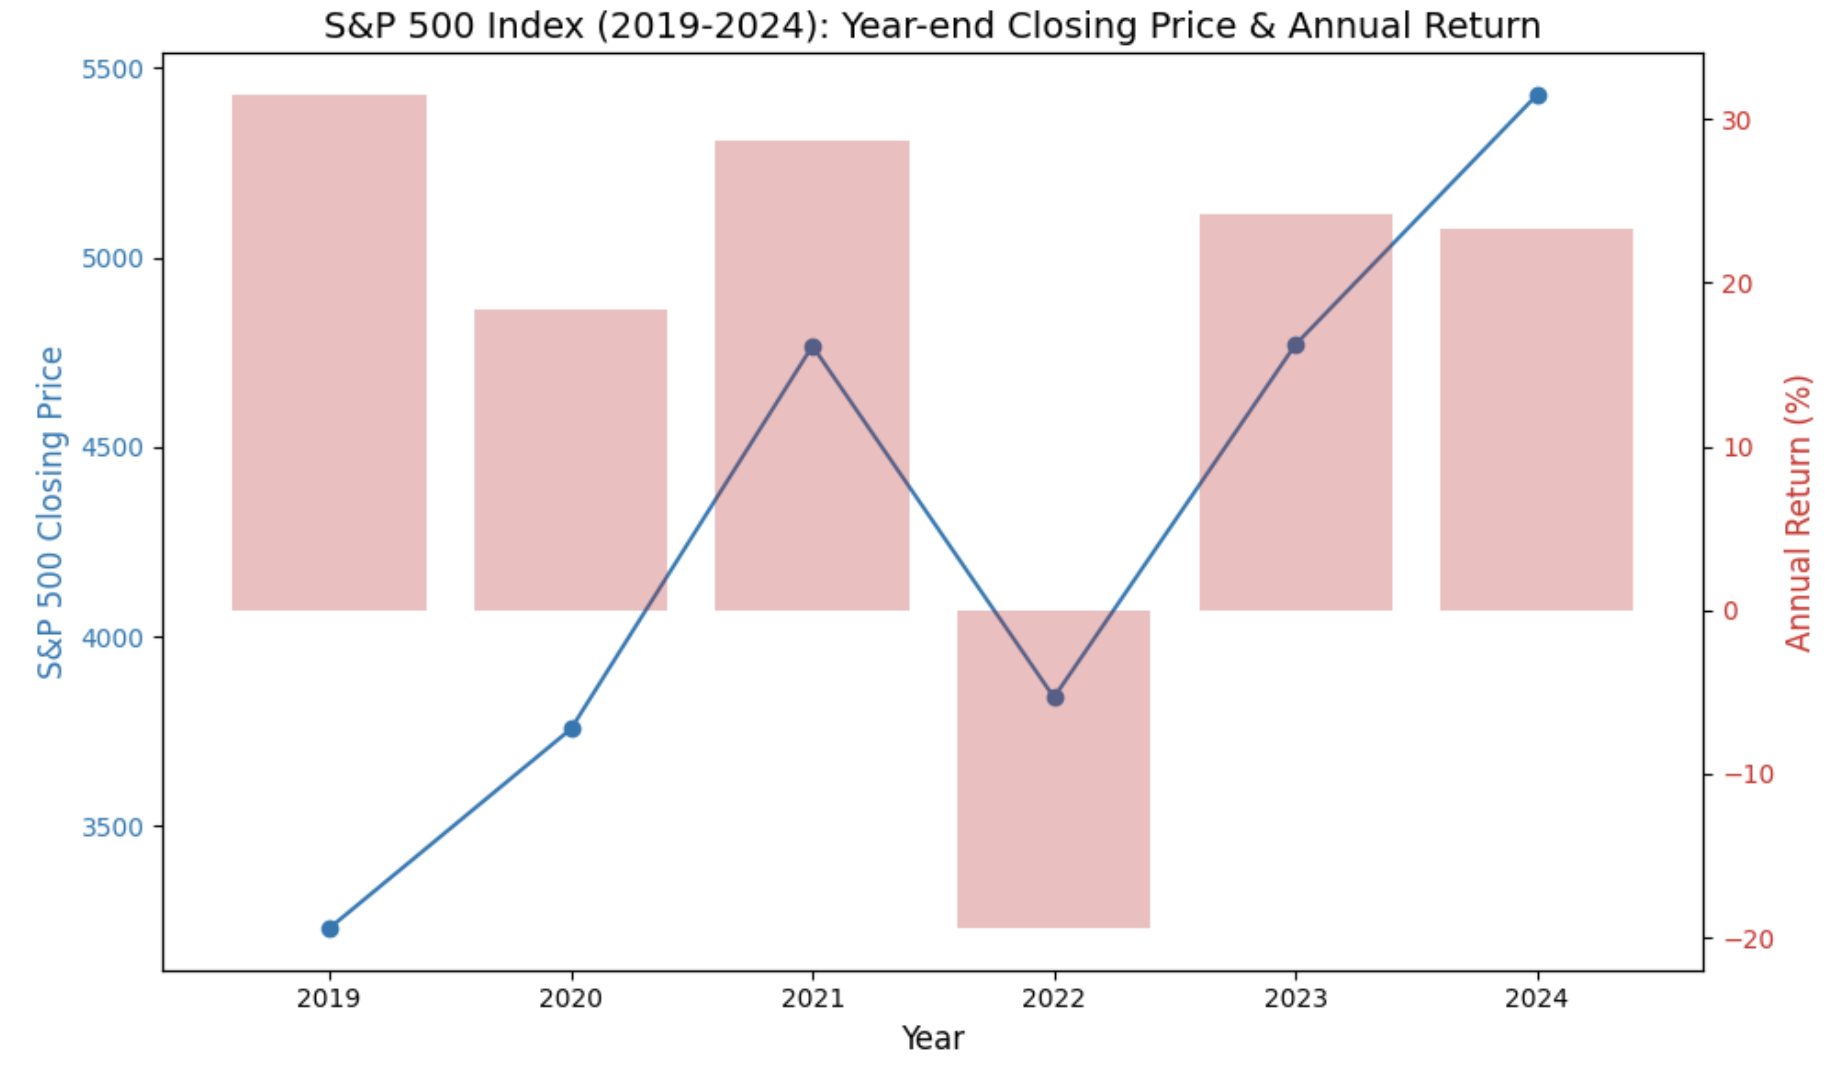

**생성한 차트 예시**

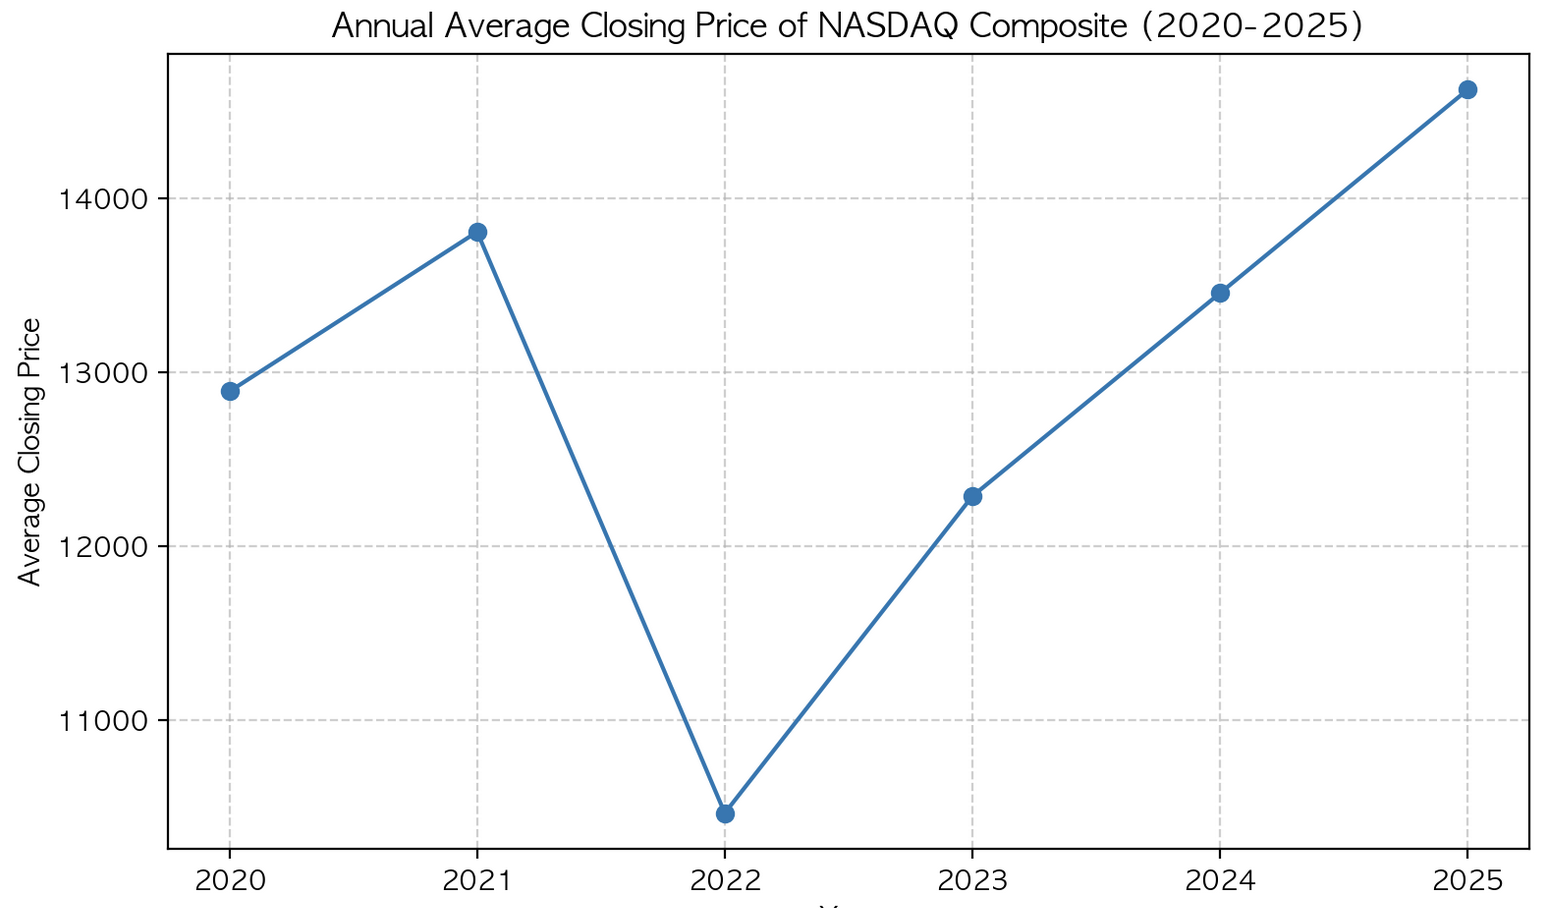

**생성한 차트 예시**

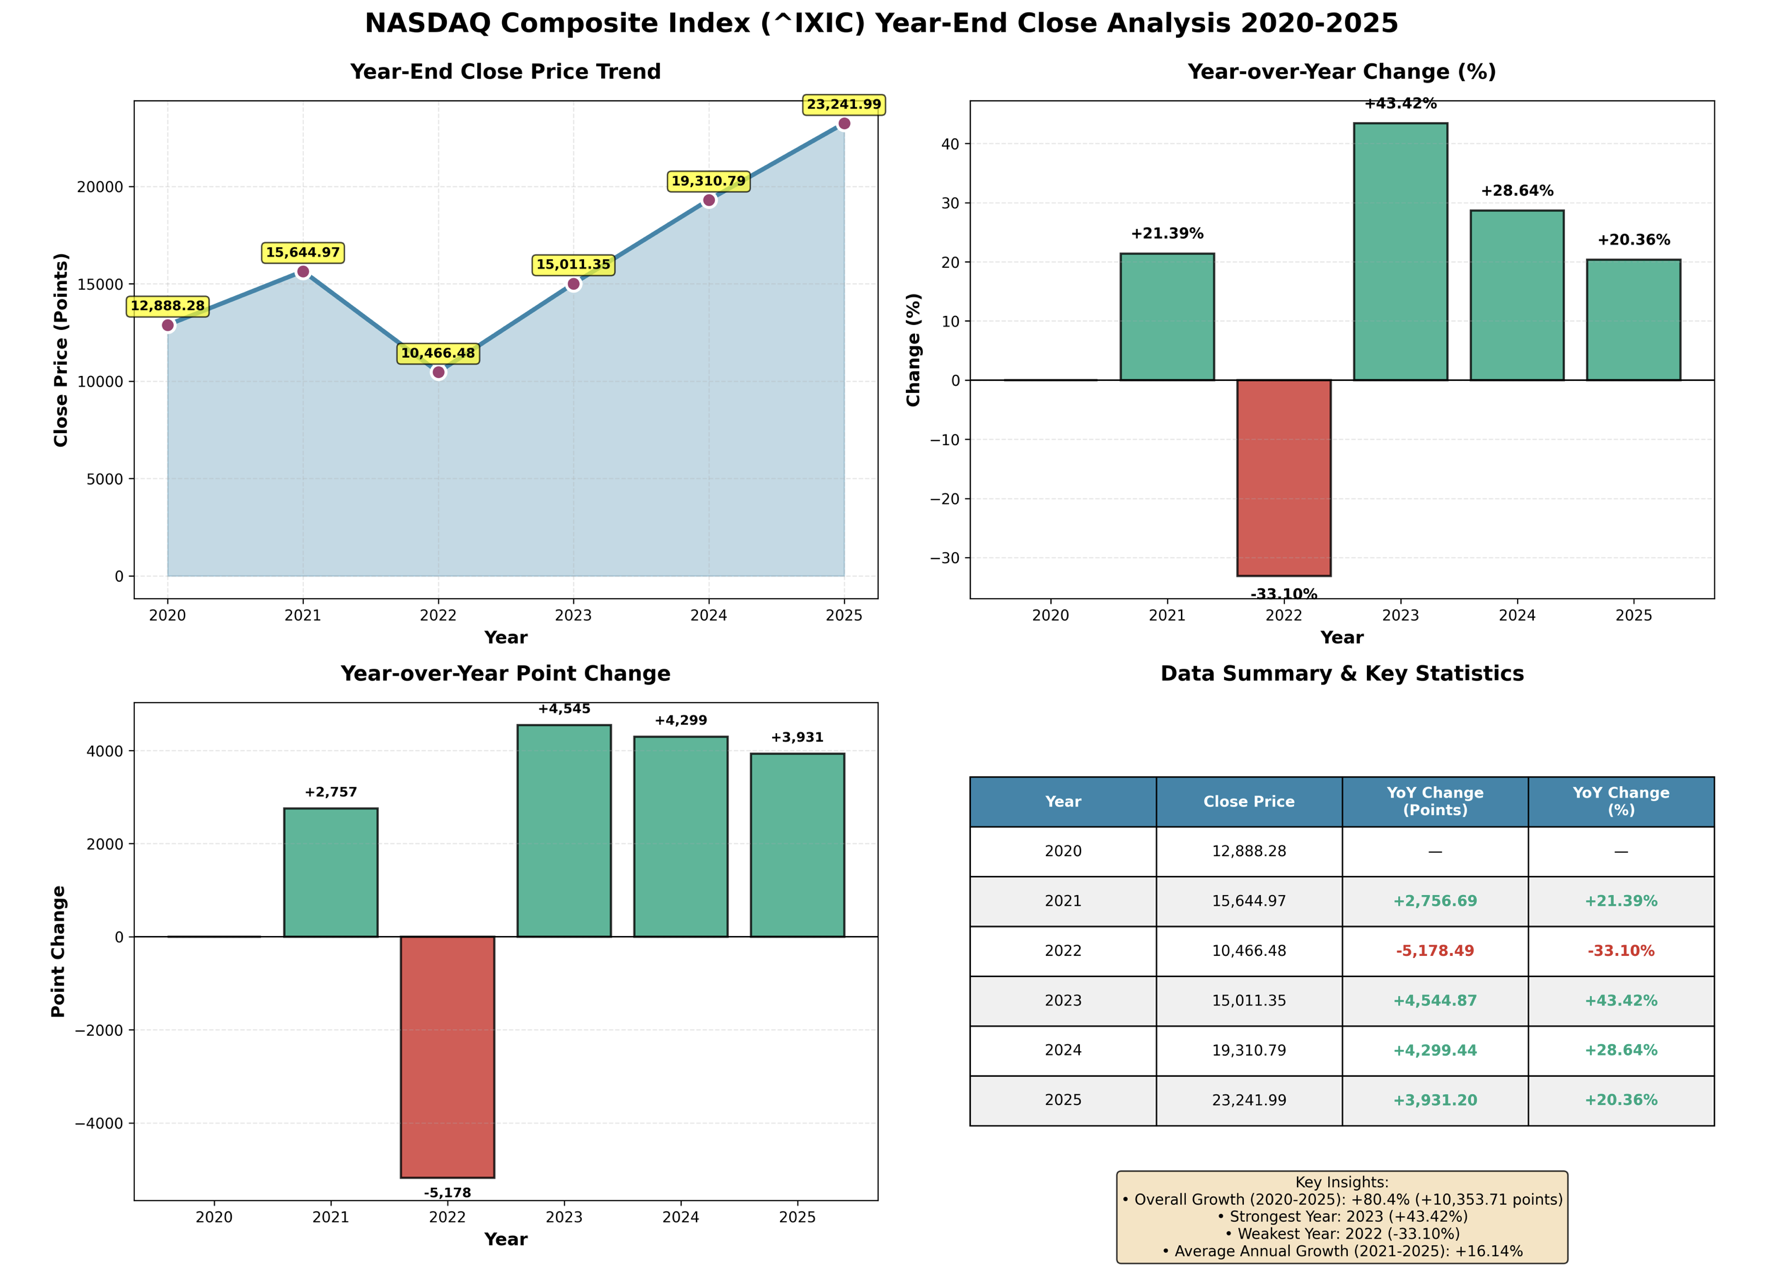

**생성한 차트 예시**

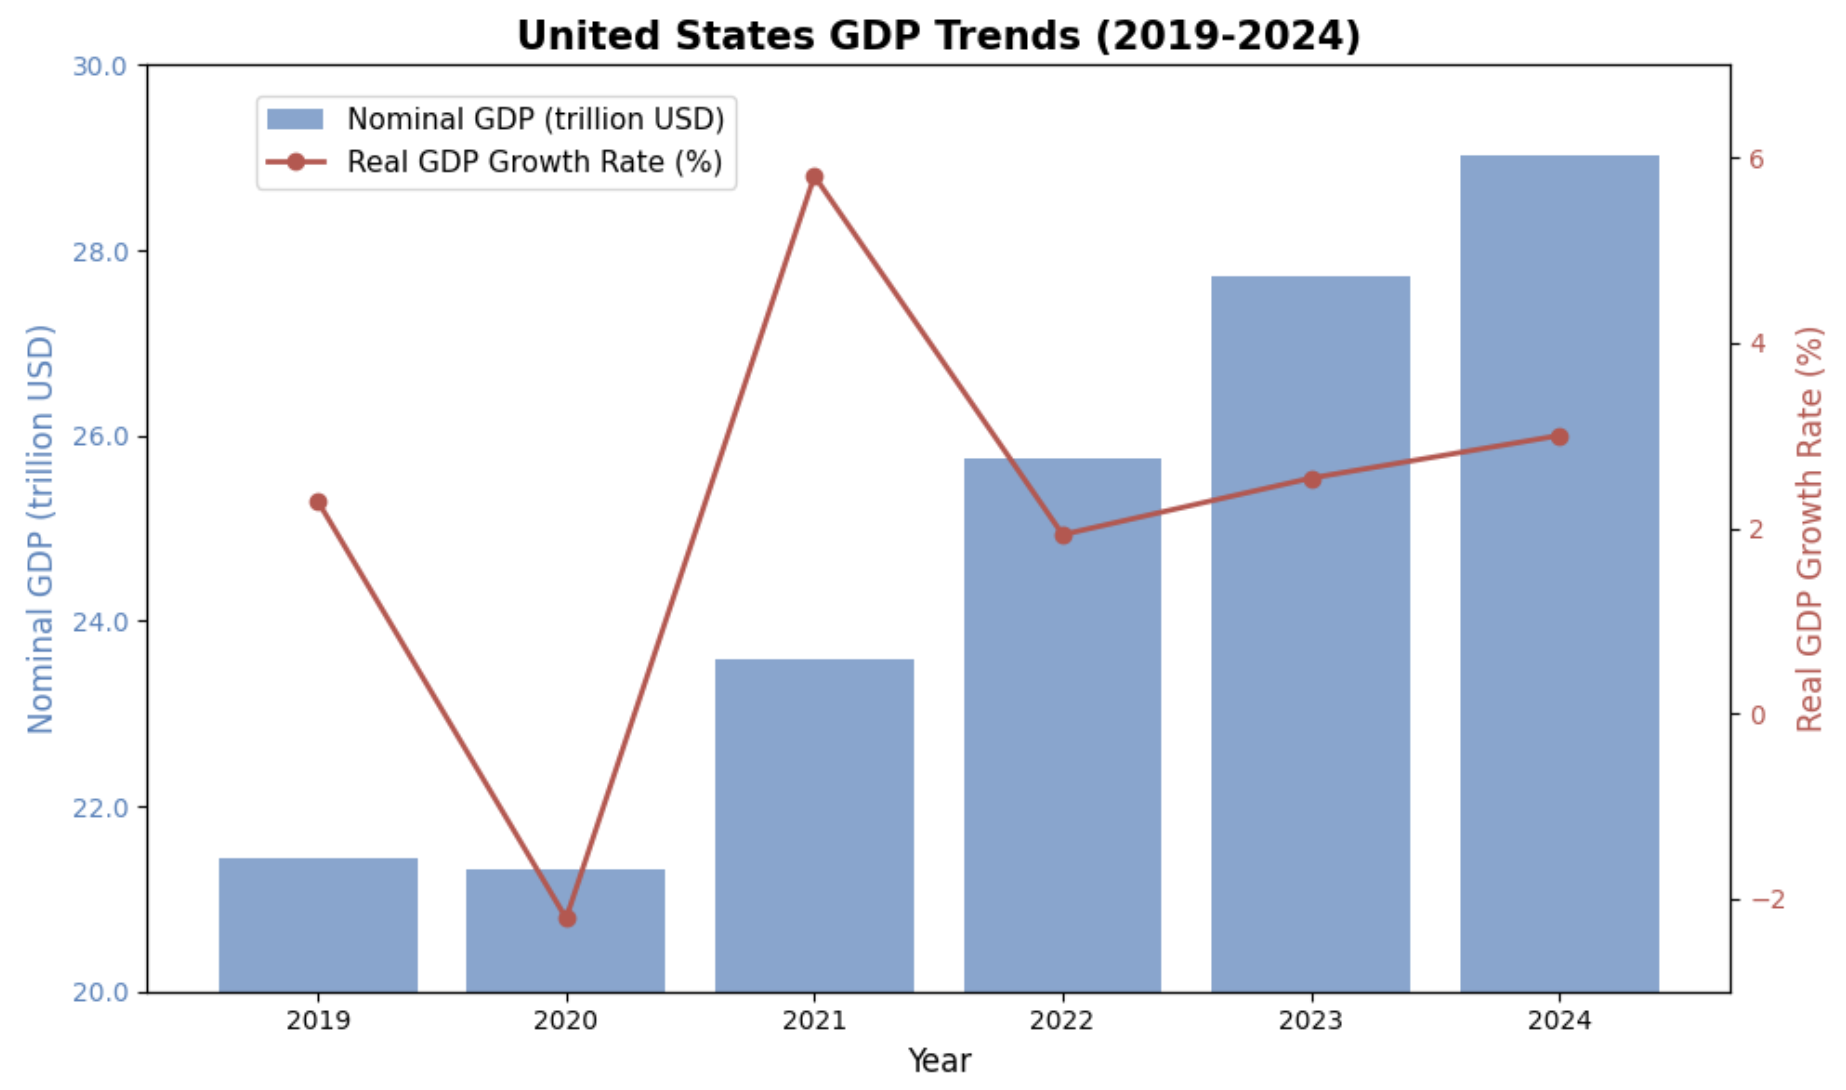

**생성한 차트 예시**

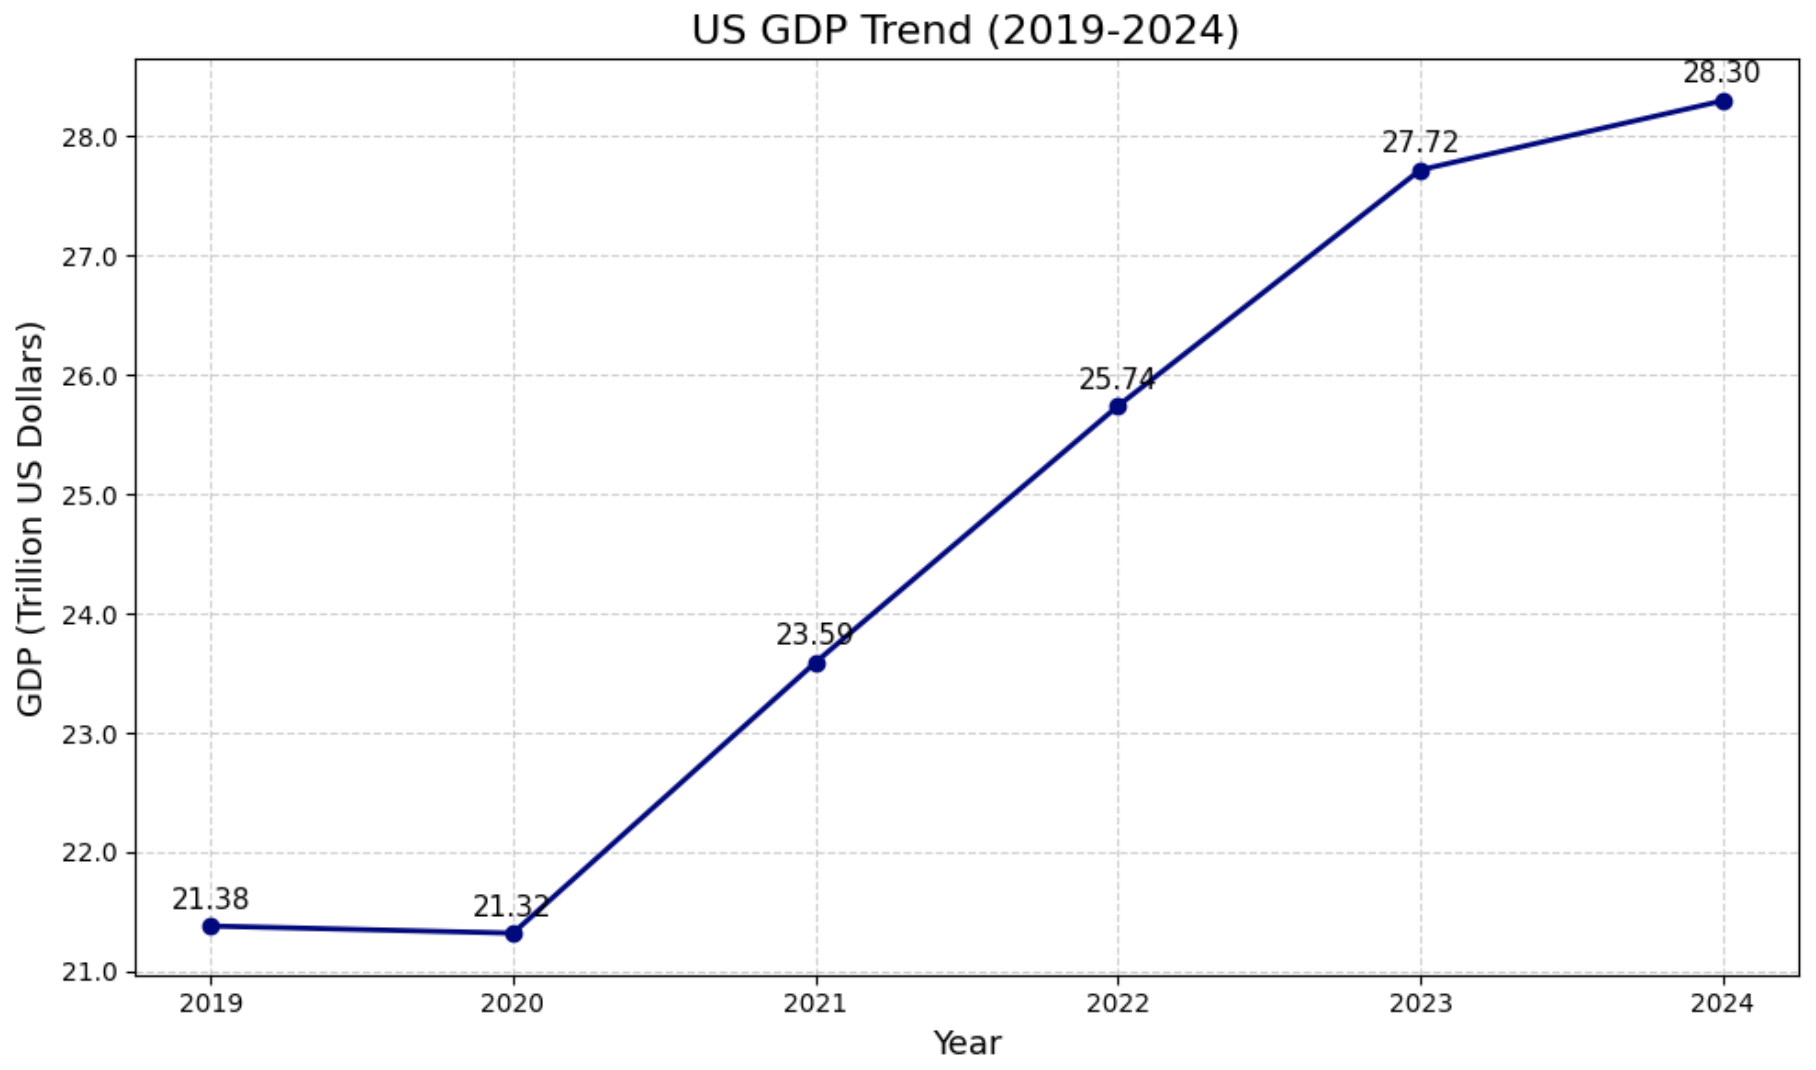

# 패키지 설치 및 API 설정

## Setting up Tools API

### Tavily

In [ ]:
# 패키지 설치하는데 1분 이상 걸릴 수 있다.
!python -m pip install -qU langchain-tavily 
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [ ]:
# --- 방법 2 - API Key를 입력한다.
import os, getpass
os.environ['TAVILY_API_KEY'] = getpass.getpass('Enter Your Tavily API Key: ')

### Python REPL Tool

In [ ]:
!python -m pip install -qU langchain-experimental
print('--- Installation Completed', '-' * 55, '\n')

## Setting Up LLM API

In [ ]:
!python -m pip install -qU python-dotenv langchain # YOUR LLM package HERE(e.g., openai anthropic google-genai groq mistralai ollama)
print('--- Installation Completed', '-' * 55, '\n')

In [ ]:
# 방법 1 - 저장한 시스템 환경 변수를 불러온다.
from dotenv import load_dotenv
load_dotenv()  # 현재 작업 디렉토리(또는 그 상위 디렉토리)에서 .env 파일을 불러온다.

In [1]:
# 방법 2 (API Key 명칭 수정 후 사용) - API Key를 입력한다.
import os, getpass
os.environ['?????_API_KEY'] = getpass.getpass('Enter Your LLM API Key: ')

Enter Your LLM API Key:  ········


# 도우미 함수 가져오기


In [ ]:
# --- utils.py 다운로드
!gdown 1UHksqU7wivF2308wDwEfz8Jf9-qsWyWi -O utils.py

# 도구 정의

## Tavily Search Tool

In [3]:
# --- 범용 웹 검색 도구 (Tavily)
from langchain.tools import tool
from langchain_tavily import TavilySearch
from typing import Any

tavily_tool = TavilySearch()
@tool(
    'web_search',
    description=(
        'Perform real-time web search using the Tavily API. '
        'Use this tool whenever up-to-date external information is required. '
        'It returns structured search results including titles, URLs, and snippets. '
        'Suitable for general research, news, reports, and technical materials.'
    )
)
def web_search(query: str) -> list[dict[str, Any]]:    
    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    result = 

    # %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    items = (
        result.get('results', [])
        if isinstance(result, dict)
        else [{'content': str(result).strip()}]
    )
    return items

In [4]:
web_search

StructuredTool(name='web_search', description='Perform real-time web search using the Tavily API. Use this tool whenever up-to-date external information is required. It returns structured search results including titles, URLs, and snippets. Suitable for general research, news, reports, and technical materials.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x108128720>)

In [6]:
web_search.invoke('오늘 미국에서 가장 화제가 되는 뉴스는 무엇인가요?')

[{'url': 'https://www.joongang.co.kr/world/northame',
  'title': '미국 1페이지 | 국제 - 중앙일보',
  'content': '도널드 트럼프 미국 행정부는 19일(현지시간) 윤석열 전 대통령이 내란 우두머리 혐의로 무기징역을 선고받은 것에 대해 구체적 입장 표명을 보류하면서도 한국 내 상황에 대한 우려를 표했다. 도널드 트럼프 미국 대통령이 19일(현지시간) 워싱턴DC 미국평화연구소에서 ‘평화위원회(Board of Peace)’ 첫 회의를 직접 주재하며 "우리가 하는 일은 아주 단순하다. 도널드 트럼프 미국 대통령이 18일(현지시간) ‘흑인 역사의 달’ 행사에서 연설하고 있다. 도널드 트럼프 미국 대통령이 가자지구 평화 정착을 위해 창설을 주도한 ‘평화위원회(Board of Peace)’ 첫 회의가 19일(현지시간) 워싱턴 DC에서 열린다. 도널드 트럼프 미국 대통령의 최측근 경제 참모인 케빈 하셋 백악관 국가경제위원회(NEC) 위원장이 18일(현지시간) ‘트럼프 행정부가 부과한 관세의 90% 이상이 미국 소비자에게 전가된다’는 뉴욕 연방준비은행의 보고서에 대해 "저자들은 징계를 받아야 한다"고 주장했다. 도널드 트럼프 미국 대통령은 17일(현지시간) 일본이 약속한 5500억 달러(약 796조원) 규모 대미 투자 첫 프로젝트로 에너지ㆍ전력ㆍ핵심광물 분야 3개 사업을 추진 중이라고 밝혔다. 러트닉 장관은 이날 성명을 통해 "트럼프 대통령이 역사적인 미ㆍ일 무역 합의의 일환으로 일본이 미국에 약속한 5500억 달러 투자 계획 중 첫 세 개 프로젝트를 승인했다"며 "이 프로젝트들은 전력 생산, 석유ㆍ가스, 첨단 제조업 등 미국 경제 핵심 분야에 360억 달러(약 52조원)를 투자하는 것을 의미한다"고 밝혔다.',
  'score': 0.44869256,
  'raw_content': None},
 {'url': 'https://www.bbc.com/korean/topics/cqywjk16v94t',
  'tit

## Python REPL Tool

- - -
**REPL**: Read-Eval-Print Loop
- REPL은 Read-Eval-Print Loop의 약자다.
- 이는 대화형 프로그래밍 환경에서 주로 사용되는 루프 구조로, 다음과 같은 과정을 반복한다.
    1.	**Read**: 사용자가 입력한 코드를 읽음
    2.	**Eval**: 입력한 코드를 실행(평가)함
    3.	**Print**: 실행 결과를 출력함
    4.	**Loop**: 이러한 과정을 반복적으로 수행함

REPL은 주로 Python, Ruby, JavaScript 등 다양한 프로그래밍 언어의 대화형 셸(interactive shell)에서 활용한다. 프로그래밍 테스트, 디버깅, 간단한 실험 등에 유용하다.
- - -

In [7]:
# --- 시각화 파이썬 코드 실행 도구 (Jupyter REPL)
from langchain.tools import tool
from langchain_experimental.utilities import PythonREPL
from IPython.display import display
from matplotlib import pyplot
from typing import Any


@tool(
    'python_repl_tool',
    description=(
        'Execute arbitrary Python code in a Jupyter notebook environment. '
        'Use this tool when you need to generate charts, run calculations, '
        'or execute Python logic. '
        'Matplotlib figures will be rendered inline automatically. '
        'The input must be valid executable Python code as a string.'
    )
)
def python_repl_tool(code: str) -> dict[str, Any]:
    repl = PythonREPL()

    try:
        # matplotlib import를 실행 환경에 보장
        exec('from matplotlib import pyplot', globals())

        # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

        result = 

        # %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

        # 현재 활성 Figure 확인
        fig = pyplot.gcf()
        if fig.axes:
            display(fig)
            pyplot.close(fig)

        return {
            'status': 'success',
            'stdout': result,
            'executed_code': code,
        }

    except Exception as err:
        return {
            'status': 'error',
            'stdout': repr(err),
            'executed_code': code,
        }

In [8]:
python_repl_tool

StructuredTool(name='python_repl_tool', description='Execute arbitrary Python code in a Jupyter notebook environment. Use this tool when you need to generate charts, run calculations, or execute Python logic. Matplotlib figures will be rendered inline automatically. The input must be valid executable Python code as a string.', args_schema=<class 'langchain_core.utils.pydantic.python_repl_tool'>, func=<function python_repl_tool at 0x109f116c0>)

Python REPL can execute arbitrary code. Use with caution.


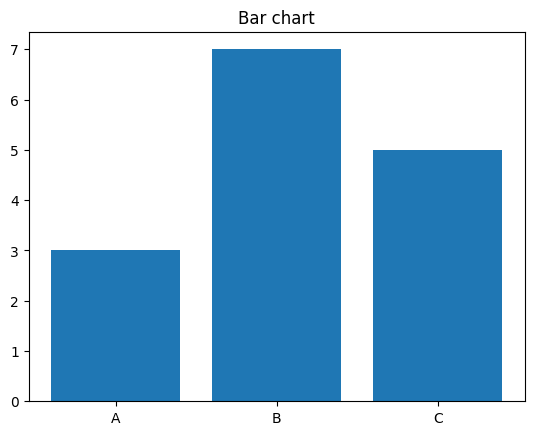

{'status': 'success',
 'stdout': '',
 'executed_code': "\nfrom matplotlib import pyplot\nx = ['A', 'B', 'C']\ny = [3, 7, 5]\npyplot.bar(x, y)\npyplot.title('Bar chart')\n"}

In [9]:
python_repl_tool.invoke("""
from matplotlib import pyplot
x = ['A', 'B', 'C']
y = [3, 7, 5]
pyplot.bar(x, y)
pyplot.title('Bar chart')
""")

# 전문 작업 에이전트 구성

## 조사 에이전트

In [10]:
# --- 시스템 프롬프트 정의
# {date} is a variable that will be replaced with the actual date.
RESEARCH_INSTRUCTION = '''
You are a research assistant responsible for conducting structured research on the user's topic.

## Workflow
1. Begin by outlining a clear task plan (a concise to-do list).
2. The first task in your plan must be to search for information on the Internet.
3. Use the provided search tool to gather relevant and reliable sources.
4. Synthesize the findings into a comprehensive answer.

## AVAILABLE TOOL
You have access to the following tool:
- `web_search`
    + Performs real-time web search using the Tavily API.
    + Suitable for retrieving up-to-date external information, including news, reports, academic sources, technical materials, and other web content.
    + Returns structured results such as titles, URLs, and snippets for further analysis or synthesis.
  
## TOOL USAGE POLICY
- You must strictly follow the call schema of the tool. Do not invent or modify parameters.
- You may call the tool multiple times if additional information is required.
- Do not split a logically related search into multiple unnecessary tool-call blocks.
- When citing external search results, you must explicitly include the source URL in the body of your response.

## Stop Immediately When
- You can comprehensively answer the user’s question with sufficient confidence.
- You have gathered enough high-quality sources to support a complete answer (typically three or more relevant sources).
- Your last two searches returned substantially similar information and no meaningful new insight.

Do not continue searching once additional tool calls are unlikely to improve answer quality.

## CONTEXT
Today’s date is {date}.
'''

In [11]:
# --- 모델 초기화
from langchain.chat_models import init_chat_model


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [12]:
# --- 에이전트 구성
from langchain.agents import create_agent


# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

researcher = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [13]:
from langchain.messages import HumanMessage
from utils import extract_text

user_message = '2020년부터 2025년까지 나스닥 지수의 연평균 종가는 어떻게 변동했나요?'

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

result_researcher = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(extract_text(result_researcher))

### 작업 계획(To-do)
1. **인터넷에서 2020~2025년 나스닥 지수(NASDAQ Composite, FRED: NASDAQCOM) ‘연간(Annual) 평균 종가’ 데이터**를 찾습니다.  
2. 연도별 평균값(연평균 종가)을 정리해 표로 제공합니다.  
3. 연도 간 변동(증감) 흐름을 요약합니다.

---

## 2020~2025년 나스닥 지수 연평균 종가(연간 평균, 시장 종가 기준)
아래 값은 FRED의 **NASDAQ Composite Index (NASDAQCOM)**에서 빈도를 **Annual(연간)**로 본 **연평균(해당 연도의 일별 종가 평균)** 값입니다.  
출처: FRED 시계열(연간 평균 확인 가능) https://fred.stlouisfed.org/series/NASDAQCOM  
(예: 2020 연간 값이 표시되는 FRED 그래프) https://fred.stlouisfed.org/graph/?g=Fdkc

| 연도 | 연평균 종가 (NASDAQ Composite, 평균) | 전년 대비 변화 |
|---|---:|---:|
| 2020 | 10,201.521 | - |
| 2021 | 14,966.170 | +46.7% |
| 2022 | 11,253.906 | -24.8% |
| 2023 | 12,957.558 | +15.1% |
| 2024 | 17,490.499 | +35.0% |
| 2025 | 20,187.189 | +15.4% |

---

## 변동 요약(흐름)
- **2020 → 2021:** 큰 폭 상승(유동성 확대와 성장주 강세 구간 영향)
- **2022:** 연평균 기준으로 **급락**(긴축/금리상승 국면에서 기술주 중심 조정)
- **2023~2025:** 회복 및 재상승 흐름  
  - 2024에 특히 강한 상승, 2025에도 추가 상승

원하시면 위 연평균을 바탕으로 **연도별 절대 증감(포인트)**, **복합연평균성장률(CAGR)**, 또는 **NASDAQ-100(나스닥100)과 비교**도

In [14]:
from rich.console import Console
from rich.markdown import Markdown
console = Console()
console.print(Markdown(extract_text(result_researcher)))

작업 계획(To-do)                                                                                                   

 1 인터넷에서 2020~2025년 나스닥 지수(NASDAQ Composite, FRED: NASDAQCOM) ‘연간(Annual) 평균 종가’ 데이터를         
   찾습니다.                                                                                                       
 2 연도별 평균값(연평균 종가)을 정리해 표로 제공합니다.                                                            
 3 연도 간 변동(증감) 흐름을 요약합니다.                                                                           

-------------------------------------------------------------------------------------------------------------------

2020~2025년 나스닥 지수 연평균 종가(연간 평균, 시장 종가 기준)                                                     

아래 값은 FRED의 **NASDAQ Composite Index (NASDAQCOM)**에서 빈도를 **Annual(연간)**로 본 연평균(해당 연도의 일별   
종가 평균) 값입니다.                                                                                               
출처: FRED 시계열(연간 평균 확인 가능) https://fred.stlouisfed.org/series/NASDAQCOM                                
(예: 2020 연간 값이 표시되는 FRED 그래프) https://fred.stlouisfed.org/graph/?g=Fdkc                                

                                                            
 연도  연평균 종가 (NASDAQ Composite, 평균)  전년 대비 변화 
 ────────────────────────────────────────────────────────── 
 2020                            10,201.521               - 
 2021                            14,966.170          +46.7% 
 2022                            11,253.906          -24.8% 
 2023                            12,957.558          +15.1% 
 2024                            17,490.499          +35.0% 
 2025                            20,187.189          +15.4% 
                                                            

-------------------------------------------------------------------------------------------------------------------

변동 요약(흐름)                                                                                                    

 • 2020 → 2021: 큰 폭 상승(유동성 확대와 성장주 강세 구간 영향)                                                    
 • 2022: 연평균 기준으로 급락(긴축/금리상승 국면에서 기술주 중심 조정)                                             
 • 2023~2025: 회복 및 재상승 흐름                                                                                  
    • 2024에 특히 강한 상승, 2025에도 추가 상승                                                                    

원하시면 위 연평균을 바탕으로 연도별 절대 증감(포인트), 복합연평균성장률(CAGR), 또는 NASDAQ-100(나스닥100)과 비교도
같이 계산해드릴게요.

## 차트 생성 에이전트

In [15]:
# --- 시스템 프롬프트 정의
CHART_INSTRUCTION = '''You are a chart-generation assistant responsible for creating and displaying charts using Python.

When numerical data is provided, you must generate a chart using matplotlib and execute the code using the tool `python-repl-tool`.

Rules:

1. All text used in the chart (titles, labels, legends, annotations, tick labels) must be written strictly in English.
   Do not use any non-English characters in the chart.
   This is required to prevent font-related rendering issues.

2. Always generate and display a chart whenever numerical data is given.

3. The Python code must:
   - Use matplotlib (pyplot).
   - Include `pyplot.show()` as the very last line.
   - Not contain any Markdown formatting.
   - Be valid executable Python code.

4. You must call the tool `python-repl-tool` to execute the Python code.
   Do not merely describe the code. The tool must be used to run the chart.

5. Do not output explanatory text unless necessary.
   Focus on generating correct Python code and executing it via the tool.

6. After the tool executes successfully, do not repeat the code or tool output.
   Simply ensure the chart is displayed. 

The tool available to you:

- python-repl-tool:
  Executes arbitrary Python code in a Jupyter notebook environment and renders matplotlib figures inline.

Always ensure the final result displays a chart successfully.
'''

In [16]:
# --- 모델 초기화

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [17]:
# --- 에이전트 구성

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

chart_generator = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

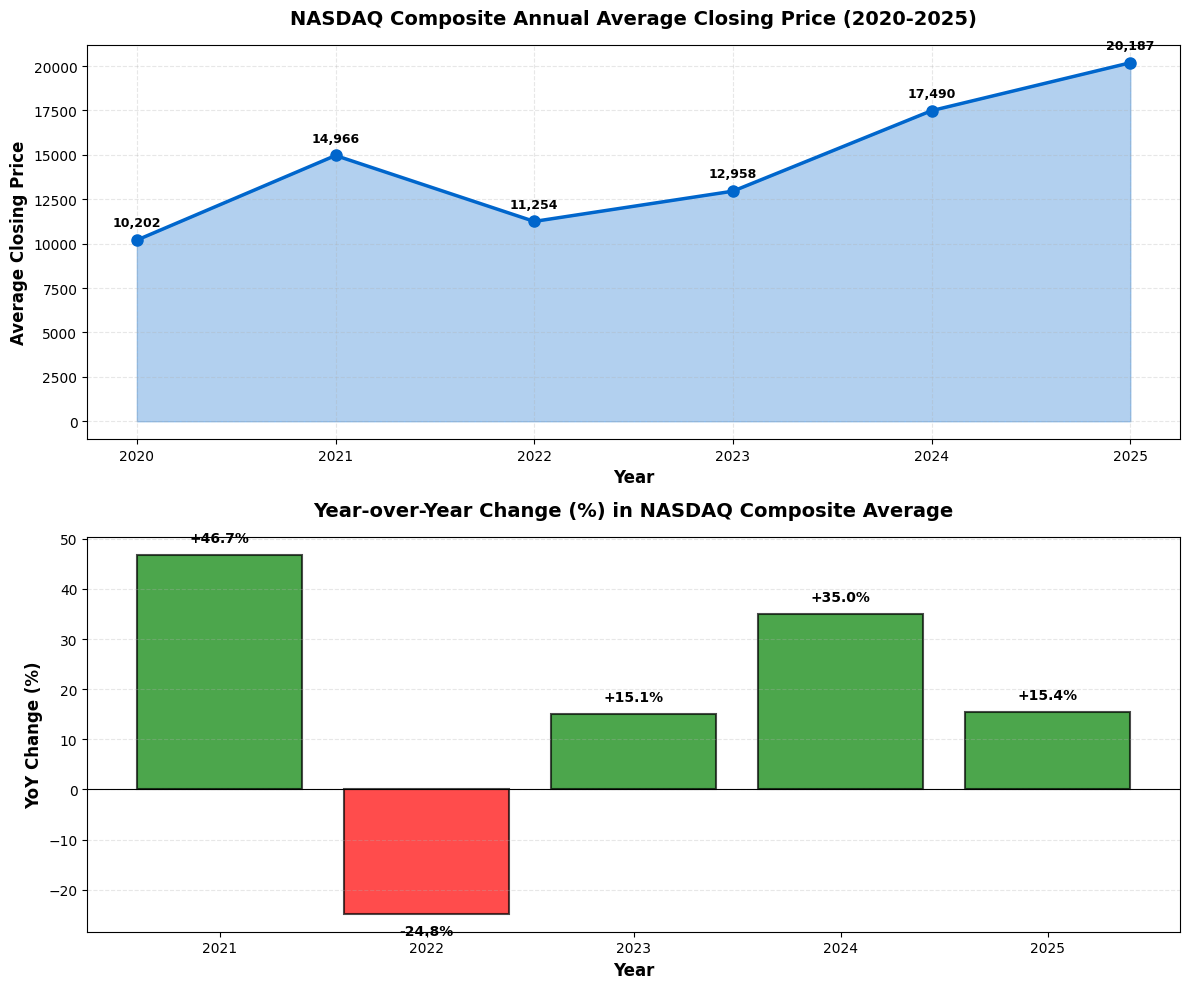

차트가 성공적으로 생성되었습니다! 

**차트 설명:**
- **상단 차트**: 2020~2025년 나스닥 지수 연평균 종가의 추세를 보여줍니다
  - 2021년까지 급상승
  - 2022년 하락 조정
  - 2023년부터 다시 회복하여 2025년 최고치 경신

- **하단 차트**: 전년 대비 증감률(%)을 막대 그래프로 표현
  - 녹색(상승): 2021년(+46.7%), 2023년(+15.1%), 2024년(+35.0%), 2025년(+15.4%)
  - 빨간색(하락): 2022년(-24.8%)

추가로 필요하신 분석(CAGR 계산, 절대 증감 포인트, 다른 지수와 비교 등)이 있으시면 말씀해주세요!


<Figure size 640x480 with 0 Axes>

In [18]:
user_message = extract_text(result_researcher)

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

result_chart = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

print(extract_text(result_chart))

In [19]:
console.print(Markdown(extract_text(result_chart)))

차트가 성공적으로 생성되었습니다!                                                                                  

차트 설명:                                                                                                         

 • 상단 차트: 2020~2025년 나스닥 지수 연평균 종가의 추세를 보여줍니다                                              
    • 2021년까지 급상승                                                                                            
    • 2022년 하락 조정                                                                                             
    • 2023년부터 다시 회복하여 2025년 최고치 경신                                                                  
 • 하단 차트: 전년 대비 증감률(%)을 막대 그래프로 표현                                                             
    • 녹색(상승): 2021년(+46.7%), 2023년(+15.1%), 2024년(+35.0%), 2025년(+15.4%)                                   
    • 빨간색(하락): 2022년(-24.8%)                                                                                 

추가로 필요하신 분석(CAGR 계산, 절대 증감 포인트, 다른 지수와 비교 등)이 있으시면 말씀해주세요!

# 전문 작업 에이전트를 도구로 감싸기

## 조사 도구

In [20]:
@tool(
    'research_tool',
    description=(
        'Invoke the research specialist agent via this tool to perform structured web research. '
        'Use this tool when external information gathering and synthesis are required. '
        'Input: request (user question). Output: final synthesized answer text.'
    )
)
def research_tool(request: str) -> str:

    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    result = 

    # %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    return extract_text(result)

In [21]:
research_tool

StructuredTool(name='research_tool', description='Invoke the research specialist agent via this tool to perform structured web research. Use this tool when external information gathering and synthesis are required. Input: request (user question). Output: final synthesized answer text.', args_schema=<class 'langchain_core.utils.pydantic.research_tool'>, func=<function research_tool at 0x10d969c60>)

## 차트 생성 도구

In [22]:
@tool(
    'chart_tool',
    description=(
        'Invoke the chart-generation specialist agent via this tool to create and display charts. '
        'Use this tool when numerical data requires visualization. '
        'Input: request (chart instruction or numerical data). '
        'Output: final agent response text after chart execution.'
    )
)
def chart_tool(request: str) -> str:

    # %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

    result = 

    # %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
    
    return extract_text(result)

In [23]:
chart_tool

StructuredTool(name='chart_tool', description='Invoke the chart-generation specialist agent via this tool to create and display charts. Use this tool when numerical data requires visualization. Input: request (chart instruction or numerical data). Output: final agent response text after chart execution.', args_schema=<class 'langchain_core.utils.pydantic.chart_tool'>, func=<function chart_tool at 0x10d9696c0>)

# 오케스트레이터(중앙 조정) 에이전트 구성

In [24]:
# --- 시스템 프롬프트 정의
# {date} is a variable that will be replaced with the actual date.
INSTRUCTION = '''You are an orchestrator agent that answers the user by using tools when appropriate.

Available tools:
- research_tool: use for web research and up-to-date/external information.
- chart_tool: use for creating charts when the user provides numerical data or asks for visualization.

Rules:
1. If the user needs up-to-date or external information, call `research_tool`.
2. If the user asks for a chart or provides numerical data to visualize, call `chart_tool`.
3. If both are needed, call `research_tool` first, then `chart_tool` using the structured numbers from research.
4. Do not reveal tool calls or internal steps. Only show the final answer.
5. Write the final answer in the same language as the user’s message.

Today’s date is {date}.
'''

In [25]:
# --- 모델 초기화
# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

model = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [26]:
# --- 에이전트 구성

# %%% YOUR CODE HERE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

orchestrator = 

# %%% END of YOUR CODE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

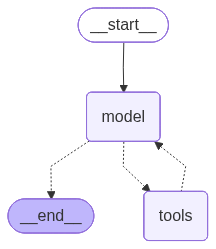

In [27]:
orchestrator

# 실행

S&P 500 지수의 2020년부터 2025년까지의 연평균 종가 데이터를 조사하겠습니다.작업 계획:
1. 인터넷에서 S&P 500의 연도별 평균 종가(annual average closing price) 자료를 검색합니다.
2. 2020~2025년 수치가 포함된 신뢰 가능한 표/데이터 출처를 확인합니다.
3. 각 연도별 수치를 정리하고, 출처 URL과 함께 답변합니다.아래 수치는 **각 연도의 거래일별 S&P 500 종가를 산술평균한 “연평균 종가(annual average closing price)”**입니다. 단위는 **S&P 500 지수 포인트**이며, 연말 종가가 아닙니다.

| 연도 | S&P 500 연평균 종가 |
|---:|---:|
| 2020 | 3,217.86 |
| 2021 | 4,273.39 |
| 2022 | 4,098.51 |
| 2023 | 4,283.73 |
| 2024 | 5,428.24 |
| 2025 | 6,216.87 |

**출처 및 확인 URL**

- 2020: StatMuse, “The average closing price for the S&P 500 (GSPC) in 2020 was $3,217.86”  
  https://www.statmuse.com/money/ask/s-and-p-500-values-by-month-2020
- 2021: StatMuse, “The average closing price for the S&P 500 (GSPC) in 2021 was $4,273.39”  
  https://www.statmuse.com/money/ask/s-and-p-500-values-by-month-2021
- 2022: StatMuse, “The average closing price for the S&P 500 (GSPC) in 2022 was $4,098.51”  
  https://www.statmuse.com/money/ask/s-and-p-ending-value-month-by-month-2022

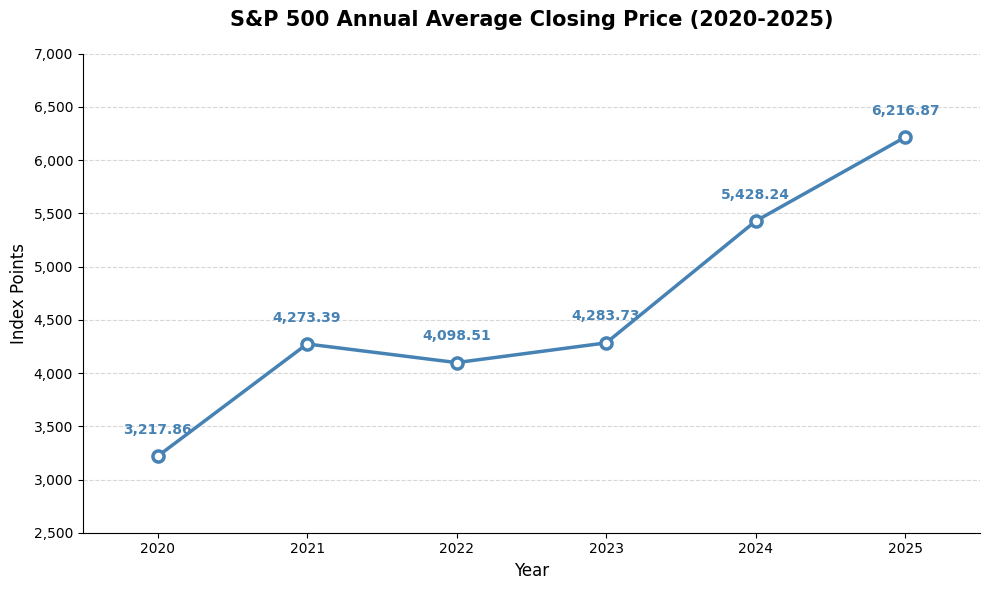

S&P 500 연평균 종가 선 그래프가 완성되었습니다! 📈

### 차트 주요 특징
- **기간**: 2020년 ~ 2025년 (6개년)
- **각 데이터 포인트**: 원형 마커와 함께 수치값 표시
- **주요 흐름 요약**:
  - 2020 → 2021: 큰 폭 상승 (+1,055.53p)
  - 2021 → 2022: 소폭 하락 (-174.88p)
  - 2022 → 2023: 소폭 반등 (+185.22p)
  - 2023 → 2024: 큰 폭 상승 (+1,144.51p)
  - 2024 → 2025: 지속 상승 (+788.63p)

2022년 일시적 조정을 제외하고는 전반적인 **강한 상승 추세**가 뚜렷하게 나타납니다.## S&P 500 연평균 종가 변동 분석 (2020–2025)

위 그래프와 함께 연도별 연평균 종가는 다음과 같습니다.

| 연도 | 연평균 종가 (지수 포인트) | 전년 대비 변화 |
|---:|---:|---:|
| 2020 | 3,217.86 | — |
| 2021 | 4,273.39 | ▲ +1,055.53 (+32.8%) |
| 2022 | 4,098.51 | ▼ −174.88 (−4.1%) |
| 2023 | 4,283.73 | ▲ +185.22 (+4.5%) |
| 2024 | 5,428.24 | ▲ +1,144.51 (+26.7%) |
| 2025 | 6,216.87 | ▲ +788.63 (+14.5%) |

### 주요 설명

**1. 2020년 — 팬데믹 충격과 회복 (3,217.86)**
코로나19로 3월에 급락했으나, 대규모 금융·재정 부양책과 저금리 환경 덕분에 빠르게 반등했습니다.

**2. 2021년 — 강한 상승 (4,273.39, +32.8%)**
경기 회복 기대, 유동성 풍부, 기업 실적 개선으로 가장 큰 폭의 연간 상승을 기록했습니다.

**3. 2022년 — 유일한 하락 (4,098.51, −4.1%)**
인플레이션 급등과 미 연준의 공격적 금리 인상이 증시를 압박하며 6년 중 유일하게 연평균이 하락

<Figure size 640x480 with 0 Axes>

In [26]:
import uuid
from utils import streaming_chat_with_turn_sep

thread_id = uuid.uuid4()
config = {'configurable': {'thread_id': thread_id}}

user_message = '''2020년부터 2025년까지 S&P 500 지수의 연평균 종가는 어떻게 변동했나요?
그래프로도 보여 주고, 설명도 해 주세요.
'''

last_message = {}  
last_msg_id = None  # 메시지 경계 감지: id가 바뀌면 streaming_chat_with_turn_sep이 줄바꿈 출력
for state in orchestrator.stream(
    {'messages': user_message}, 
    config=config,
    stream_mode=['messages', 'values']
):
    mode, chunk = state  
    if mode == 'messages':
        last_msg_id = streaming_chat_with_turn_sep(chunk, last_msg_id)
    if mode == 'values':
        last_message.update(chunk)  # 마지막 chunk가 최종 상태

In [27]:
for message in last_message['messages']:
    message.pretty_print()

================================ Human Message =================================

2020년부터 2025년까지 S&P 500 지수의 연평균 종가는 어떻게 변동했나요?
그래프로도 보여 주고, 설명도 해 주세요.

================================== Ai Message ==================================

[{'text': 'S&P 500 지수의 2020년부터 2025년까지의 연평균 종가 데이터를 조사하겠습니다.', 'type': 'text', 'index': 0}, {'id': 'toolu_01NbcEbvhSA98qBeasio8umE', 'caller': {'type': 'direct'}, 'input': {}, 'name': 'research_tool', 'type': 'tool_use', 'index': 1, 'partial_json': '{"request": "2020년부터 2025년까지 S&P 500 지수의 연평균 종가(annual average closing price) 데이터를 각 연도별로 알려주세요. 2020, 2021, 2022, 2023, 2024, 2025년 각각의 연평균 종가 수치를 제공해 주세요."}'}]
Tool Calls:
  research_tool (toolu_01NbcEbvhSA98qBeasio8umE)
 Call ID: toolu_01NbcEbvhSA98qBeasio8umE
  Args:
    request: 2020년부터 2025년까지 S&P 500 지수의 연평균 종가(annual average closing price) 데이터를 각 연도별로 알려주세요. 2020, 2021, 2022, 2023, 2024, 2025년 각각의 연평균 종가 수치를 제공해 주세요.
================================= Tool Message =================================
Name

In [28]:
print(extract_text(last_message))

## S&P 500 연평균 종가 변동 분석 (2020–2025)

위 그래프와 함께 연도별 연평균 종가는 다음과 같습니다.

| 연도 | 연평균 종가 (지수 포인트) | 전년 대비 변화 |
|---:|---:|---:|
| 2020 | 3,217.86 | — |
| 2021 | 4,273.39 | ▲ +1,055.53 (+32.8%) |
| 2022 | 4,098.51 | ▼ −174.88 (−4.1%) |
| 2023 | 4,283.73 | ▲ +185.22 (+4.5%) |
| 2024 | 5,428.24 | ▲ +1,144.51 (+26.7%) |
| 2025 | 6,216.87 | ▲ +788.63 (+14.5%) |

### 주요 설명

**1. 2020년 — 팬데믹 충격과 회복 (3,217.86)**
코로나19로 3월에 급락했으나, 대규모 금융·재정 부양책과 저금리 환경 덕분에 빠르게 반등했습니다.

**2. 2021년 — 강한 상승 (4,273.39, +32.8%)**
경기 회복 기대, 유동성 풍부, 기업 실적 개선으로 가장 큰 폭의 연간 상승을 기록했습니다.

**3. 2022년 — 유일한 하락 (4,098.51, −4.1%)**
인플레이션 급등과 미 연준의 공격적 금리 인상이 증시를 압박하며 6년 중 유일하게 연평균이 하락한 해입니다.

**4. 2023년 — 완만한 반등 (4,283.73, +4.5%)**
긴축이 정점에 다다랐다는 기대와 AI 관련 기술주 강세가 회복을 견인했습니다.

**5. 2024년 — 큰 폭 상승 (5,428.24, +26.7%)**
금리 인하 기대, AI 투자 붐, 견조한 기업 실적이 맞물리며 다시 강한 상승세를 보였습니다.

**6. 2025년 — 지속 상승 (6,216.87, +14.5%)**
상승 추세가 이어지며 처음으로 연평균 6,000포인트를 돌파했습니다.

### 종합
2022년의 일시적 조정을 제외하면 2020년부터 2025년까지 S&P 500은 **전반적으로 강한 우상향 추세**를 보였으며, 6년간 연평

In [29]:
console.print(Markdown(extract_text(last_message)))

S&P 500 연평균 종가 변동 분석 (2020–2025)                                                                          

위 그래프와 함께 연도별 연평균 종가는 다음과 같습니다.                                                             

                                                       
 연도  연평균 종가 (지수 포인트)        전년 대비 변화 
 ───────────────────────────────────────────────────── 
 2020                   3,217.86                     — 
 2021                   4,273.39  ▲ +1,055.53 (+32.8%) 
 2022                   4,098.51     ▼ −174.88 (−4.1%) 
 2023                   4,283.73     ▲ +185.22 (+4.5%) 
 2024                   5,428.24  ▲ +1,144.51 (+26.7%) 
 2025                   6,216.87    ▲ +788.63 (+14.5%) 
                                                       

주요 설명                                                                                                          

1. 2020년 — 팬데믹 충격과 회복 (3,217.86) 코로나19로 3월에 급락했으나, 대규모 금융·재정 부양책과 저금리 환경 덕분에
빠르게 반등했습니다.                                                                                               

2. 2021년 — 강한 상승 (4,273.39, +32.8%) 경기 회복 기대, 유동성 풍부, 기업 실적 개선으로 가장 큰 폭의 연간 상승을  
기록했습니다.                                                                                                      

3. 2022년 — 유일한 하락 (4,098.51, −4.1%) 인플레이션 급등과 미 연준의 공격적 금리 인상이 증시를 압박하며 6년 중    
유일하게 연평균이 하락한 해입니다.                                                                                 

4. 2023년 — 완만한 반등 (4,283.73, +4.5%) 긴축이 정점에 다다랐다는 기대와 AI 관련 기술주 강세가 회복을             
견인했습니다.                                                                                                      

5. 2024년 — 큰 폭 상승 (5,428.24, +26.7%) 금리 인하 기대, AI 투자 붐, 견조한 기업 실적이 맞물리며 다시 강한        
상승세를 보였습니다.                                                                                               

6. 2025년 — 지속 상승 (6,216.87, +14.5%) 상승 추세가 이어지며 처음으로 연평균 6,000포인트를 돌파했습니다.          

종합                                                                                                               

2022년의 일시적 조정을 제외하면 2020년부터 2025년까지 S&P 500은 전반적으로 강한 우상향 추세를 보였으며, 6년간      
연평균 종가는 약 3,218 → 6,217포인트로 약 93% 상승했습니다. 특히 2021년과 2024년의 큰 폭 상승이 전체 성장을        
주도했습니다.                                                                                                      

※ 데이터 출처: StatMuse(S&P Dow Jones Indices 기준). 연평균 종가는 연말 종가가 아니라 해당 연도 거래일 종가의      
산술평균이며, 2025년 수치는 집계 시점 기준 잠정치일 수 있습니다.

# Lab: 멀티턴 메모리 추가하기

- - -

**목표**
- 실습에서 구성한 오케스트레이터(중앙 조정) 에이전트에 **대화 기록(checkpointer)** 을 연결하여, 같은 `thread_id`로 **두 번째 질문**을 보낼 때 이전 조사 및 차트 맥락을 이어 받도록 확장한다.
- 1턴에서 조사와 차트를 만든 뒤, 2턴에서는 **재검색 없이** 차트 형식만 바꾸는 후속 요청을 처리한다.

**요구사항**

1. `langgraph.checkpoint.memory.InMemorySaver`로 체크포인터를 생성하고, 오케스트레이터 `create_agent` 호출에 `checkpointer` 인자로 연결한다.
2. `uuid`로 `thread_id`를 생성하고, **1턴·2턴 모두 동일한** `config = {'configurable': {'thread_id': ...}}` 를 사용한다.
3. 오케스트레이터 시스템 프롬프트에 **후속 턴 규칙**을 추가한다. 사용자가 차트 스타일과 시각화 방식만 바꿔 달라고 하면, 이전 턴에서 확보한 수치를 재사용하고 `chart_tool` 위주로 처리하며, 새로운 데이터나 다른 주제를 요청할 때만 `research_tool`을 다시 호출한다.
4. **1턴** 테스트: 지수·통계 등 수치 조사 + 차트 생성을 요청한다(예: S&P 500 연평균 종가 추이를 꺾은선 그래프로).
5. **2턴** 테스트: 1턴과 **같은 데이터**로 막대 그래프 등 **시각화만 변경**하도록 요청한다. 2턴에서 `research_tool`을 다시 호출하지 않거나, 호출하더라도 불필요한 재검색이 아님을 설명할 수 있어야 한다.
6. 2턴 실행 후 `result['messages']`를 출력하여, Human/AI/Tool 메시지가 **한 스레드에 누적**되었음을 보여 준다.

**최소 테스트 질문**

다음 두 질문을 **같은 `thread_id`** 로 순서대로 테스트한다.

1. **'2020년부터 2025년까지 S&P 500 지수의 연평균 종가는 어떻게 변동했나요? 꺾은선 그래프로 보여 주고, 설명도 해 주세요.'**
2. **'방금 조사한 같은 데이터로 막대 그래프로 다시 그려 주세요. 수치는 그대로 두고 시각화만 바꿔 주세요.'**

**제출 안내**        
- 제출 파일은 `.ipynb` 노트북 파일이다.
- 기존 실습 코드 아래에 과제 코드를 추가하여 제출한다.
- 코드를 모르는 사람도 이해할 수 있도록 코드에 친절하고 상세한 주석을 포함한다.

<details>
<summary><b>클릭하여 💡힌트 보기</b></summary>

- `thread_id`만 config에 넣고 `checkpointer`를 붙이지 않으면 대화가 이어지지 않는다.
    +  챗봇 실습의 `InMemorySaver` + `checkpointer` 패턴을 참고한다.
- 1턴과 2턴에 **다른** `thread_id`를 쓰면 매번 새 대화가 시작된다.
    +  따라서 과제 검증용으로는 하나의 `thread_id` 변수를 재사용한다.
- 후속 턴에서 `research_tool` 호출을 줄이려면, 시스템 프롬프트에 '차트 형식 변경만 요청되면 `chart_tool`만 사용' 같은 규칙을 **명시적으로** 적는다.
- `invoke`와 `stream` 모두 `config`에 같은 `thread_id`를 넘기면 된다.
    + 과제 제출본에서는 `invoke` 두 번으로 검증해도 충분하다.


</details>

- - -

In [ ]:
# YOUR CODE HERE

**1턴: 조사 + 차트 (실습과 동일한 유형의 질문)**

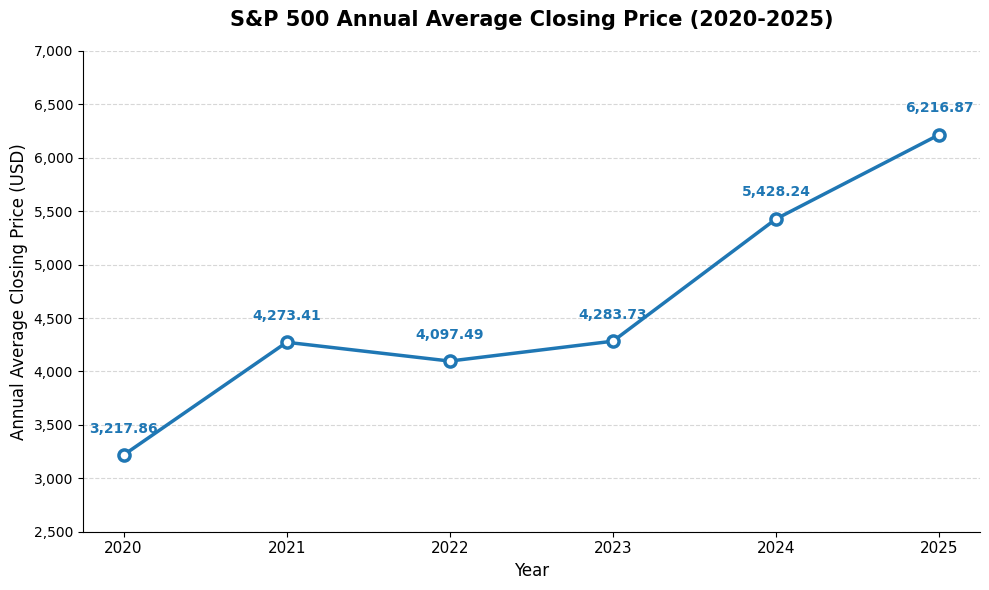

2020년부터 2025년까지 S&P 500 지수의 연평균 종가 추이를 꺾은선 그래프로 정리해 드렸습니다.

## 연도별 S&P 500 연평균 종가

| 연도 | 연평균 종가 | 전년 대비 변동 |
|---:|---:|---:|
| 2020 | 3,217.86 | — |
| 2021 | 4,273.41 | **+32.8%** 📈 |
| 2022 | 4,097.49 | **-4.1%** 📉 |
| 2023 | 4,283.73 | **+4.5%** 📈 |
| 2024 | 5,428.24 | **+26.8%** 🚀 |
| 2025 | 6,216.87 | **+14.5%** 🚀 |

## 주요 흐름 설명

- **2020 → 2021 (+32.8%)**: 코로나19 팬데믹으로 인한 급락 이후 강력한 회복세를 보였습니다. 대규모 유동성 공급과 저금리 환경이 증시 상승을 이끌었습니다.
- **2021 → 2022 (-4.1%)**: 인플레이션 급등과 연준의 금리 인상 우려로 시장 변동성이 커지며 소폭 하락했습니다.
- **2022 → 2023 (+4.5%)**: 하락 이후 안정세를 찾으며 완만하게 회복했습니다.
- **2023 → 2024 (+26.8%)**: AI 열풍과 기업들의 견조한 실적에 힘입어 대폭 상승했습니다.
- **2024 → 2025 (+14.5%)**: 상승세가 이어지며 6,216.87로 사상 최고 수준에 도달했습니다.

## 종합 정리

전체 기간을 보면 S&P 500 연평균 종가는 2020년 약 3,218에서 2025년 약 6,217로 **약 93% 상승**했습니다. 2022년의 일시적 조정을 제외하면 대체로 우상향하는 흐름을 보였으며, 특히 2021년과 2024년의 두 차례 강한 상승이 두드러집니다.

> 참고: 위 수치는 S&P 500 **가격지수**(총수익 및 물가 조정 미반영)의 일별 종가를 연간 평균한 값이며, 주요 출처는 Macrotrends이고 FRED·Yahoo Finance 데이터를 교차 확인했습니다.

추가로 막대그래프 등 다른 형태

<Figure size 640x480 with 0 Axes>

In [31]:
# YOUR CODE HERE

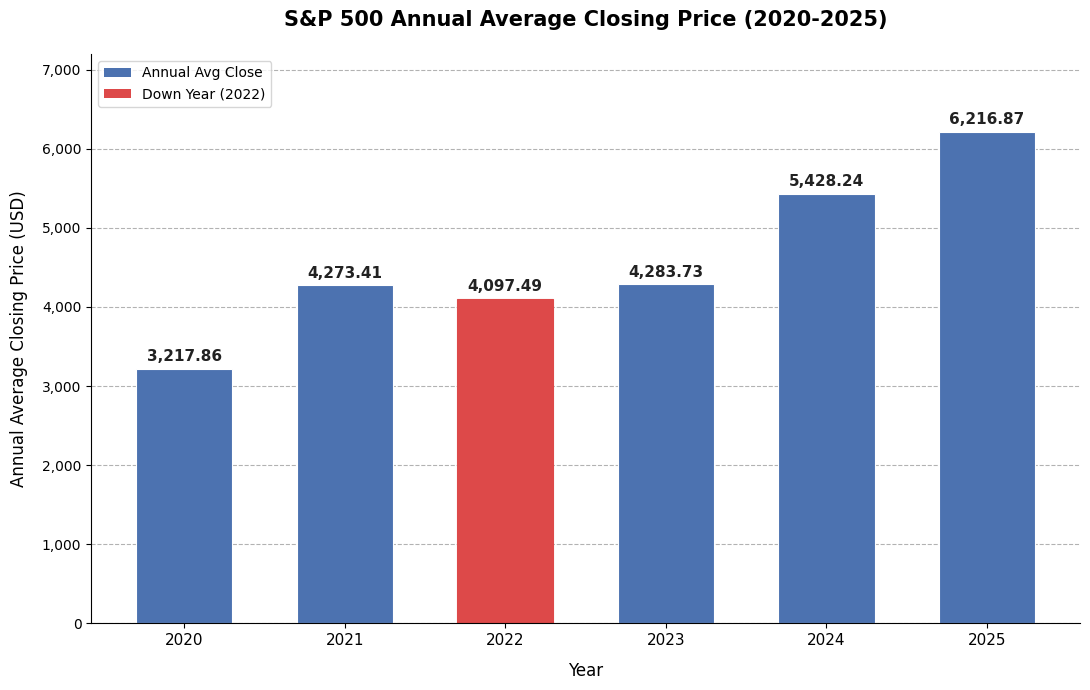

같은 데이터를 막대그래프로 다시 그려 드렸습니다. 수치는 이전과 동일하게 유지했습니다.

## S&P 500 연평균 종가 (막대그래프)

| 연도 | 연평균 종가 | 전년 대비 변동 |
|---:|---:|---:|
| 2020 | 3,217.86 | — |
| 2021 | 4,273.41 | **+32.8%** 📈 |
| 2022 | 4,097.49 | **-4.1%** 📉 *(유일한 하락 연도)* |
| 2023 | 4,283.73 | **+4.5%** 📈 |
| 2024 | 5,428.24 | **+26.7%** 🚀 |
| 2025 | 6,216.87 | **+14.5%** 🚀 |

## 주요 포인트

- 📈 **2021년**: 약 33%의 큰 상승으로 가장 두드러진 해입니다.
- 📉 **2022년**: 해당 기간 중 유일한 하락 연도로, 금리 인상 압박과 변동성을 반영합니다.
- 🚀 **2024~2025년**: 강한 상승세가 이어지며 연평균 기준 처음으로 6,000을 돌파했습니다.

막대그래프는 연도별 수치의 절대적 크기 비교에 유리하여, 각 연도 간 종가 차이를 한눈에 직관적으로 파악할 수 있습니다. 다른 시각화 형태나 추가 분석이 필요하시면 말씀해 주세요!


<Figure size 640x480 with 0 Axes>

In [32]:
# YOUR CODE HERE

In [33]:
# 2턴 이후 state에는 Human/AI/Tool 메시지가 누적되어야 한다.
# YOUR CODE HERE

message count: 10
================================ Human Message =================================

2020년부터 2025년까지 S&P 500 지수의 연평균 종가는 어떻게 변동했나요?
꺾은선 그래프로 보여 주고, 설명도 해 주세요.

================================== Ai Message ==================================

[{'text': "I'll research the annual average closing prices of the S&P 500 from 2020 to 2025 and then create a line chart for you.", 'type': 'text'}, {'id': 'toolu_01SkJbXR4nXGPBeJUCbjtLiv', 'caller': {'type': 'direct'}, 'input': {'request': 'What was the annual average closing price (yearly average of daily closing values) of the S&P 500 index for each year from 2020 to 2025? Please provide a number for each year: 2020, 2021, 2022, 2023, 2024, and 2025 (year-to-date if 2025 is incomplete).'}, 'name': 'research_tool', 'type': 'tool_use'}]
Tool Calls:
  research_tool (toolu_01SkJbXR4nXGPBeJUCbjtLiv)
 Call ID: toolu_01SkJbXR4nXGPBeJUCbjtLiv
  Args:
    request: What was the annual average closing price (yearly average of daily closing v

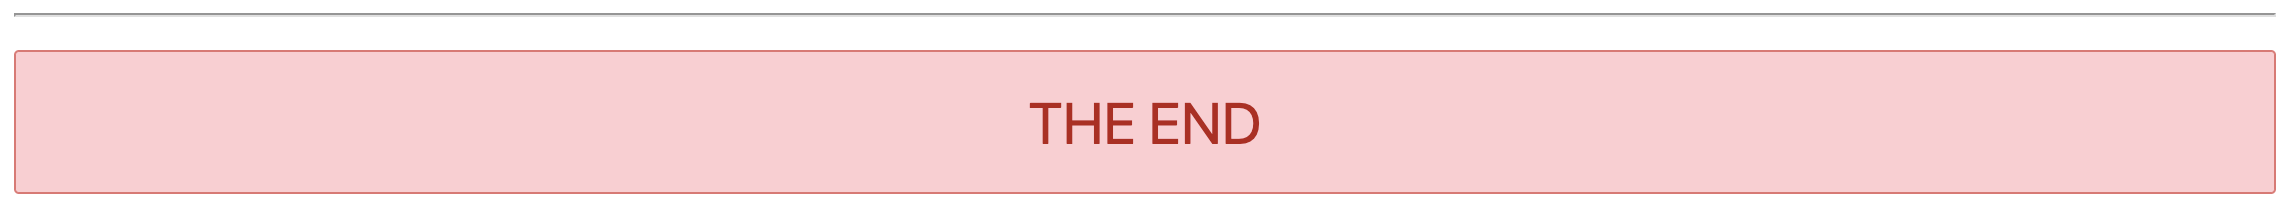